# Task 2 — DINOv2-small Feature Extraction
## Dataset: Cats vs Dogs

This notebook applies the **facebook/dinov2-small** vision transformer to extract feature
representations for the Cats vs Dogs dataset. The extracted embeddings are further processed
using PCA, t-SNE, K-Means clustering, and a 70/10/20 train-validation-test split for
classification.

The main goals are:

- loading and preprocessing the Cats vs Dogs image dataset
- extracting DINOv2 feature embeddings
- applying dimensionality reduction (PCA, t-SNE)
- clustering using K-Means
- training a classifier to evaluate discriminative performance

## Installing Required Libraries

The `transformers` and `timm` packages are installed to enable loading the pretrained
DINOv2-small image model.

In [2]:
!pip install transformers timm

Defaulting to user installation because normal site-packages is not writeable


## Importing Dependencies

All core libraries required for data loading, feature extraction, dimensionality reduction,
clustering, and evaluation are imported in this cell. This includes:
- PyTorch and Torchvision for image handling
- scikit-learn for PCA, t-SNE, clustering, and classification
- Transformers for loading the DINOv2 feature extractor
- Matplotlib for visualisation

In [3]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, davies_bouldin_score

import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

C:\Users\ALIENWARE JM\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Path, Image Transformations, and Balanced Subset Creation

The dataset directory is specified, and a preprocessing pipeline is defined to resize all
images to `(224, 224)` and convert them into PyTorch tensors suitable for the DINOv2-small
feature extractor.

The dataset is loaded using `ImageFolder`, after which a **balanced subset** of
**1000 Cat images** and **1000 Dog images** is created to ensure an equal representation
of both classes. This helps avoid class imbalance and supports fair evaluation of the
downstream clustering and classification tasks.

A `DataLoader` is then constructed to iterate over the balanced dataset in batches, enabling
efficient feature extraction using the DINOv2 model.

In [4]:
data_path = "data/kagglecatsanddogs/PetImages"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ds = datasets.ImageFolder(data_path, transform=transform)

# Balanced subset for Cats vs Dogs, subset for Oxford Pets
if "Cats vs Dogs" == "Cats vs Dogs":
    samples = ds.samples
    cats = [s for s in samples if "Cat" in s[0]][:1000]
    dogs = [s for s in samples if "Dog" in s[0]][:1000]
    ds.samples = cats + dogs
else:
    ds.samples = ds.samples[:3000]

dl = DataLoader(ds, batch_size=32, shuffle=False)

print("Classes:", ds.classes)
print("Total samples:", len(ds.samples))


Classes: ['Cat', 'Dog']
Total samples: 2000


## Device Setup and Loading DINOv2-small Model

This cell detects whether a CUDA-enabled GPU is available and loads the pretrained
**facebook/dinov2-small** model along with its corresponding image processor.

The model is placed in evaluation mode to ensure deterministic inference.

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
model.eval()

to_pil = transforms.ToPILImage()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Feature Extraction Using DINOv2-small and Saving Output Files

A feature extraction function is implemented to convert image tensors to PIL format, apply the
DINOv2 image processor, and obtain feature embeddings from the **CLS token** of the model’s
last hidden state. The function aggregates all extracted feature vectors along with their
corresponding labels and returns them as NumPy arrays.

This function is then applied to the balanced Cats vs Dogs dataset, producing a feature matrix
representing all images. The extracted embeddings and labels are saved to the directory
`output_catsvsdogs/` for further analysis.

The primary outputs generated are:

- `features.csv` — containing the DINOv2 CLS-token feature vectors
- printed summary of the extracted feature matrix shape

These embeddings serve as the basis for dimensionality reduction, clustering, and downstream
classification.

In [6]:
def extract_features(loader):
    all_feats, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            pil_images = [to_pil(img) for img in x]  # convert tensor -> PIL
            inputs = processor(images=pil_images, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            cls_feats = outputs.last_hidden_state[:, 0, :]  # CLS token

            all_feats.append(cls_feats.cpu().numpy())
            all_labels.append(y.numpy())
    return np.vstack(all_feats), np.hstack(all_labels)

features, labels = extract_features(dl)

os.makedirs("output_catsvsdogs", exist_ok=True)
pd.DataFrame(features).to_csv("output_catsvsdogs/features.csv", index=False)

print("Feature matrix shape:", features.shape)


Feature matrix shape: (2000, 384)


## Creating Train, Validation, and Test Splits

A **70/30** split is applied first to separate training data from temporary evaluation data.
The remaining 30% is split into:

- **Validation set (10%)**
- **Test set (20%)**

The splits are stratified to preserve class balance across partitions.

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    features, labels, test_size=0.30, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (1400, 384)
Validation: (200, 384)
Test: (400, 384)


## Dimensionality Reduction Using PCA and t-SNE

To better understand the structure of the DINOv2-small feature embeddings, dimensionality
reduction is applied in two stages:

1. **PCA (Principal Component Analysis)**
   PCA reduces the high-dimensional CLS-token feature vectors into 50 principal components.
   This transformation captures the most informative variance in the data while significantly
   lowering dimensionality for downstream clustering and visualisation tasks.

2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
   A 2D t-SNE projection is computed using the PCA-reduced features.
   This non-linear method produces an interpretable visual representation of the dataset,
   revealing how Cat and Dog samples are distributed in the embedded space.

The resulting t-SNE coordinates are saved to `output_catsvsdogs/tsne.csv`, and a scatterplot
is generated to illustrate the class separation achieved by the DINOv2-small embeddings.

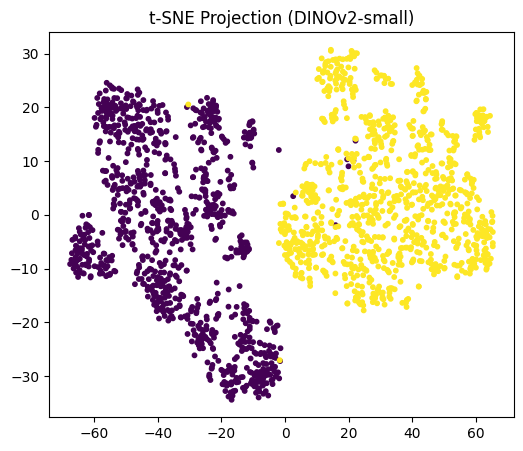

In [8]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(features)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

pd.DataFrame(X_tsne).to_csv("output_catsvsdogs/tsne.csv", index=False)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, s=10)
plt.title("t-SNE Projection (DINOv2-small)")

plt.savefig("output_catsvsdogs/tsne_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## K-Means Clustering on PCA Features

K-Means is applied with `k` equal to the number of classes (Cats, Dogs).
The Davies–Bouldin Index is computed to evaluate cluster compactness and separation.

Lower DB index values indicate better clustering quality.

In [9]:
k = len(np.unique(labels))
km = KMeans(n_clusters=k, random_state=42)
clusters = km.fit_predict(X_pca)

db_idx = davies_bouldin_score(X_pca, clusters)
print("Davies–Bouldin Index:", db_idx)


Davies–Bouldin Index: 2.4343887942781244


## Logistic Regression Classification

A Logistic Regression classifier is trained using the 70% training split.
Performance is assessed on both validation and test sets:

- Validation Accuracy
- Test Accuracy
- Classification Report
- Confusion Matrix (visualised using `imshow`)

These metrics quantify how well the DINOv2 embeddings support supervised classification.

Validation Accuracy: 1.0
Test Accuracy: 1.0

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



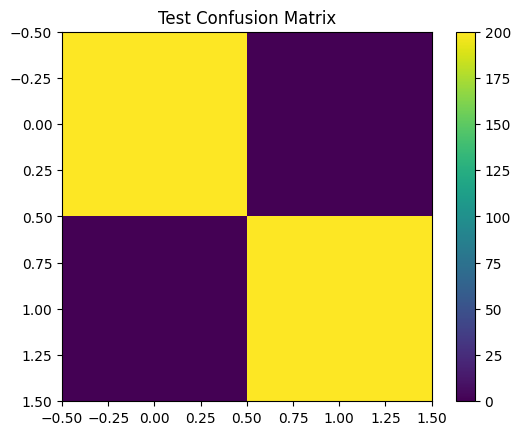

In [10]:
clf = LogisticRegression(max_iter=800)
clf.fit(X_train, y_train)

val_pred = clf.predict(X_val)
test_pred = clf.predict(X_test)

val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)
print("\nTest Classification Report:")
print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred)
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.colorbar()
plt.show()


## Creating and Saving Model Performance Summary

A summary dictionary is constructed to consolidate all key outputs from the classification
and clustering stages. This includes:

- the number of samples in the training, validation, and test sets
- the validation and test accuracies from the Logistic Regression classifier
- the Davies–Bouldin Index computed from the K-Means clustering

The summary is converted into a pandas DataFrame and saved as `summary.csv` within the
`output_catsvsdogs/` directory. This file provides a concise overview of the model's
performance and supports further reporting or comparative analysis.

In [11]:
summary = {
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "val_accuracy": val_acc,
    "test_accuracy": test_acc,
    "db_index": db_idx
}

pd.DataFrame([summary]).to_csv("output_catsvsdogs/summary.csv", index=False)
print("Summary saved to output/summary.csv")


Summary saved to output/summary.csv
